In [14]:
import pandas as pd

file_path = "/content/sample_data/iec104_treated_balanced.csv"
df = pd.read_csv(file_path)

print(df.shape)
print(df.head())

(5315, 84)
   Flow ID  Src IP  Src Port  Dst IP  Dst Port  Protocol  Timestamp  \
0       65       1     62883       6      2404         6       1742   
1       63       1     62320       6      2404         6       1746   
2       44       1     56512       6      2404         6       1748   
3       25       1     50804       6      2404         6       1750   
4       21       1     50171       6      2404         6       1752   

   Flow Duration  Total Fwd Packet  Total Bwd packets  ...  Fwd Seg Size Min  \
0         221738                38                 51  ...              20.0   
1         220298                35                 50  ...              20.0   
2         436679                32                 42  ...              20.0   
3         169353                29                 51  ...              20.0   
4         269482                53                 87  ...              20.0   

   Active Mean  Active Std  Active Max  Active Min  Idle Mean  Idle Std  \
0     

In [15]:
import numpy as np

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

print(df['Label'].value_counts())

Label
dosattack     5059
attackfree     255
Name: count, dtype: int64


In [16]:
print(df.columns.tolist())

['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',

In [ ]:
print(df.shape)

(27303, 80)


In [17]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import TensorDataset, DataLoader
import torch

def prepare_dataloaders(train_df, val_df, label_col='Label', batch_size=128):

    X_train = train_df.drop(columns=[label_col])
    y_train = train_df[label_col]

    X_val = val_df.drop(columns=[label_col])
    y_val = val_df[label_col]

    #2. Label Encoding
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_val = le.transform(y_val)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)

    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.long)

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, X_train.shape[1], len(le.classes_)



In [18]:
import torch.nn as nn

class FNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(FNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [19]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=30):

    model.to(device)

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):

        #TRAIN
        model.train()
        total_loss = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(X)

            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        #VALID
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)

                outputs = model(X)
                loss = criterion(outputs, y)

                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                total += y.size(0)
                correct += (preds == y).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f}")

    return model, train_losses, val_losses, val_accuracies

In [21]:

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Label'],
    random_state=42
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader, val_loader, input_dim, num_classes = prepare_dataloaders(train_df, val_df)

model = FNN(input_dim, num_classes)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

model, train_losses, val_losses, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=20
)

Epoch 1 | Train Loss: 0.1974 | Val Loss: 0.0154 | Val Acc: 1.0000
Epoch 2 | Train Loss: 0.0064 | Val Loss: 0.0023 | Val Acc: 1.0000
Epoch 3 | Train Loss: 0.0015 | Val Loss: 0.0012 | Val Acc: 1.0000
Epoch 4 | Train Loss: 0.0010 | Val Loss: 0.0008 | Val Acc: 1.0000
Epoch 5 | Train Loss: 0.0007 | Val Loss: 0.0006 | Val Acc: 1.0000
Epoch 6 | Train Loss: 0.0005 | Val Loss: 0.0005 | Val Acc: 1.0000
Epoch 7 | Train Loss: 0.0004 | Val Loss: 0.0004 | Val Acc: 1.0000
Epoch 8 | Train Loss: 0.0003 | Val Loss: 0.0003 | Val Acc: 1.0000
Epoch 9 | Train Loss: 0.0003 | Val Loss: 0.0002 | Val Acc: 1.0000
Epoch 10 | Train Loss: 0.0002 | Val Loss: 0.0002 | Val Acc: 1.0000
Epoch 11 | Train Loss: 0.0002 | Val Loss: 0.0001 | Val Acc: 1.0000
Epoch 12 | Train Loss: 0.0002 | Val Loss: 0.0001 | Val Acc: 1.0000
Epoch 13 | Train Loss: 0.0001 | Val Loss: 0.0001 | Val Acc: 1.0000
Epoch 14 | Train Loss: 0.0001 | Val Loss: 0.0001 | Val Acc: 1.0000
Epoch 15 | Train Loss: 0.0001 | Val Loss: 0.0001 | Val Acc: 1.0000
Epoc

In [22]:
from sklearn.metrics import classification_report

def evaluate(model, val_loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(device)

            outputs = model(X)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())

    print(classification_report(all_labels, all_preds))

evaluate(model, val_loader, device)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        51
           1       1.00      1.00      1.00      1012

    accuracy                           1.00      1063
   macro avg       1.00      1.00      1.00      1063
weighted avg       1.00      1.00      1.00      1063



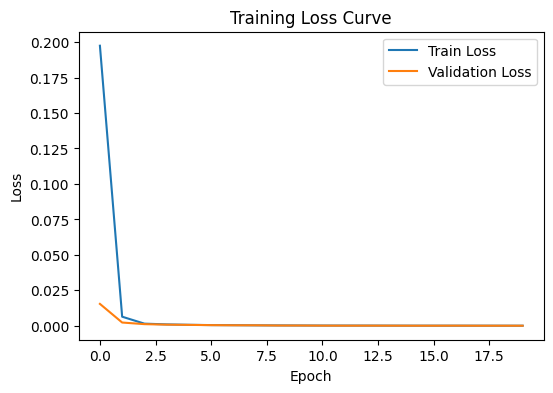

In [23]:
import matplotlib.pyplot as plt

def plot_loss(train_losses, val_losses=None):
    plt.figure(figsize=(6,4))
    plt.plot(train_losses, label='Train Loss')

    if val_losses:
        plt.plot(val_losses, label='Validation Loss')

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve")
    plt.legend()
    plt.show()

plot_loss(train_losses, val_losses)